In [1]:
from cil.io import ZEISSDataReader
import numpy as np
import os
current_directory = os.getcwd()
os.chdir('/zhome/71/c/146676/Desktop/msaca/main')
print("Current working directory:", current_directory)
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader
import plotly.graph_objects as go
import plot_library as pl
from scipy.ndimage import rotate
from scipy.interpolate import griddata
import SimpleITK as sitk
import importlib
import registrator

Current working directory: /zhome/71/c/146676


In [2]:
reconpath0 = "/dtu-compute/msaca/sliceB_xray_dtu/sliceB_xray_dtu/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"
reconpath_neutron = "/dtu-compute/msaca/sliceB_neutron_dtu/sliceB_neutron_psi/04_evaluation/fullrecon/"

In [3]:
reader = ZEISSDataReader(reconpath0)
recon_xray_ = reader.read()
recon_xray = pl.array_normalizer(recon_xray_.as_array().astype(np.float32))

In [4]:
roi = {'axis_0': (100, 1113, 1)}
reader = TIFFStackReader(reconpath_neutron,roi=roi)
recon_neutron = pl.array_normalizer(reader.read())

In [130]:
importlib.reload(registrator)

<module 'registrator' from '/zhome/71/c/146676/Desktop/msaca/main/registrator.py'>

In [131]:
reg = registrator.Registrator()
reg.load_images(recon_xray, recon_neutron)
reg_full = reg.copy()
reg_full_binary = reg.copy()
reg.downsizing(fixed_factor=3, moving_factor = 3,smooth=True)
reg_downsized = reg.copy()
reg.filter_threshold(fixed_threshold = 0.2, moving_threshold = 0.5)
reg_full_binary.filter_threshold(fixed_threshold = 0.2, moving_threshold = 0.5)

hello
hello


In [132]:
transform_centroid = reg.transformation(type='Centroid')
reg.resample(transform_centroid)

In [133]:
angle_radians = np.deg2rad(180)
rotation_matrix = [
                [1, 0, 0],
                [0, np.cos(angle_radians), -np.sin(angle_radians)],
                [0, np.sin(angle_radians), np.cos(angle_radians)]
            ]
matrix = [elem for row in rotation_matrix for elem in row]
transform_flip = reg.transformation(type='Similarity3DTransform', matrix=matrix, translation=(0,0,0))
reg.resample(transform_flip)


In [134]:
transform_registration = reg.register()
reg.resample(transform_registration)

In [135]:
# Align principal axes with coordinate axes
out = reg.compute_principal_moments_and_axes([0.5,0.5])
matrix = out['fixed']['axes'].T.flatten()
transform_coordinate_axes = reg.transformation(type='Euler3DTransform',matrix=matrix)

In [136]:
total_transform = sitk.CompositeTransform([transform_centroid, transform_flip, transform_registration,transform_coordinate_axes])
transform_fixed = reg.transformation(type='Euler3DTransform',matrix=matrix)

In [137]:
reg_full.resample(total_transform)
reg_full.resample(transform_fixed, fixed=True)
reg_downsized.resample(total_transform)
reg_downsized.resample(transform_fixed, fixed=True)
reg_full_binary.resample(total_transform)
reg_full_binary.resample(transform_fixed, fixed=True)


In [138]:
reg.resample(transform_fixed, fixed=True)
reg.resample(transform_fixed)

In [139]:
out = reg.compute_principal_moments_and_axes([0.5,0.5])
print(out)

{'fixed': {'moment': (583.7410659863851, 20813.191150727205, 46380.07910220754), 'axes': array([[ 9.99999991e-01, -4.05941448e-05,  1.29375712e-04],
       [-4.07563921e-05, -9.99999213e-01,  1.25432300e-03],
       [ 1.29324691e-04, -1.25432826e-03, -9.99999205e-01]]), 'centroid': array([-11.2892749 ,  18.48514155, -34.50963096])}, 'moving': {'moment': (655.9478796574258, 22222.649005662883, 47204.917354875), 'axes': array([[-0.99992338, -0.00459185,  0.01149575],
       [ 0.00467644, -0.99996211,  0.00734267],
       [ 0.0114616 ,  0.00739587,  0.99990696]]), 'centroid': array([ -6.38213414,  18.85375475, -39.45258228])}}


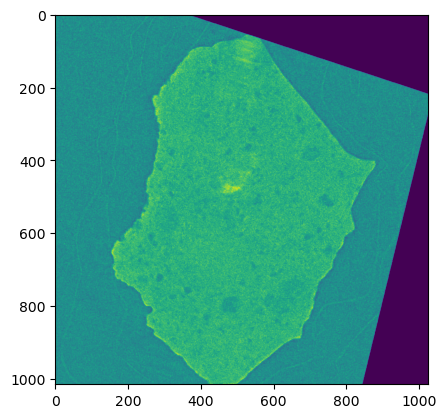

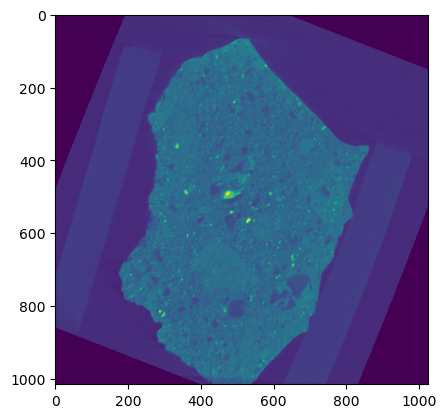

In [140]:
N = 490
plt.imshow(sitk.GetArrayFromImage(reg_full.moving)[:,:,N])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg_full.fixed)[:,:,N])
plt.show()


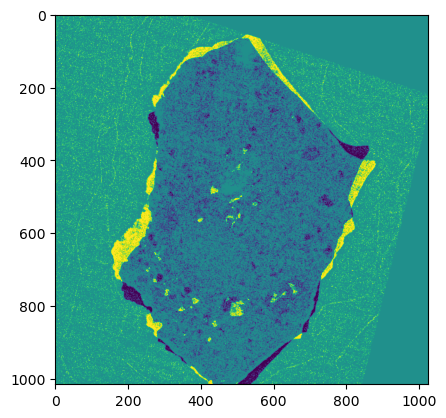

In [141]:
diff = sitk.GetArrayFromImage(reg_full_binary.moving) - sitk.GetArrayFromImage(reg_full_binary.fixed)
plt.imshow(diff[:,:,N])

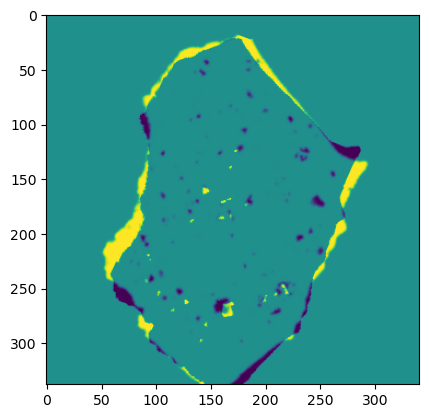

In [142]:
diff = sitk.GetArrayFromImage(reg.moving) - sitk.GetArrayFromImage(reg.fixed)
plt.imshow(diff[:,:,163])

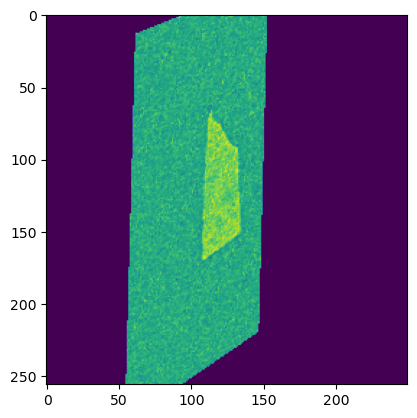

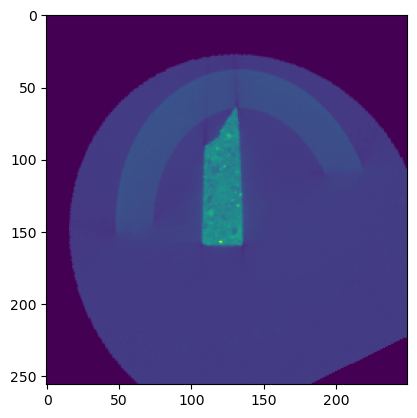

In [80]:
plt.imshow(sitk.GetArrayFromImage(reg_downsized.moving)[50])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg_downsized.fixed)[50])
plt.show()

(254, 256, 250)


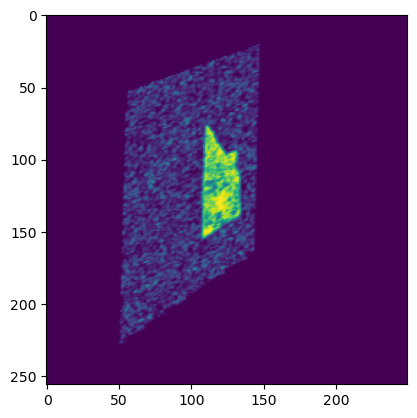

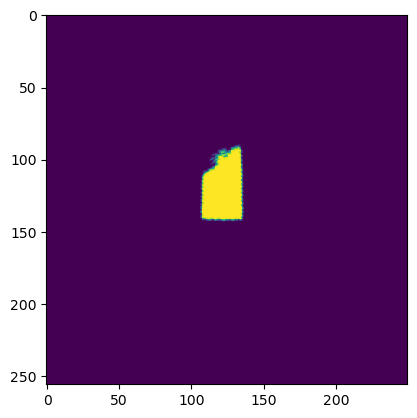

In [81]:
print(np.shape(sitk.GetArrayFromImage(reg.moving)))
plt.imshow(sitk.GetArrayFromImage(reg.moving)[30])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg.fixed)[30])
plt.show()

In [82]:
recons = Registrator(fixed_data=recon_xray, moving_data=recon_neutron)
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'fixed')
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'moving')
print('Downsizing finished')
#recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = False)
recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = True)

#recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = False)
recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = True)

NameError: name 'Registrator' is not defined

In [ ]:
recons.set_main(downsized = True, mask = True)
recons.transform_initial()
matrix = (0.8160936658664071, -0.28856459951138586, 0.02374979627874302, 0.2766920759330827, 0.7563278026519324, -0.31820151230511134, 0.08529405624244589, 0.3074754937003145, 0.8050007435556675)
translation = (15.245151809618564, 15.175912405966365, -20.850352829049456)
scale = 1.0 #0.8652125177637796
recons.apply_similarity_transform(matrix,translation,scale)
angle_degrees = 180
recons.rotate_about_yz_plane(angle_degrees,axis='x')

In [ ]:
#recons.SetupRegistration()
#recons.ExecuteRegistration()
#params = recons.get_transformation_parameters()
evals, evecs = recons.compute_principal_moments_and_axes()
principal1 = recons.get_largest_eigenvector(evals, evecs, rank = 1)
principal2 = recons.get_largest_eigenvector(evals, evecs, rank = 2)
centroid = recons.get_centroid()
print(principal1)
print(principal2)
print(centroid)
recons.create_mirroring_transform([0,0,0]], principal1, principal2)

[-0.1292231   0.18383061  0.97442686]
[ 0.94714112 -0.26810932  0.17618481]
[45.594781707719115, 51.91145857862761, 57.97386144209485]


In [ ]:
# Code: 
# Matrix: (0.8160936658664071, -0.28856459951138586, 0.02374979627874302, 0.2766920759330827, 0.7563278026519324, -0.31820151230511134, 0.08529405624244589, 0.3074754937003145, 0.8050007435556675)
# Versor:(0.18667249795024038, -0.01836190339688423, 0.16864592205798945, 0.9676645968443155)
# Translation: (15.245151809618564, 15.175912405966365, -20.850352829049456)
# Scale: 0.8652125177637796
# Center: (0.0, 0.0, 0.0)
#pars = recons.registration_transform.GetNthTransform(0).GetScale()
#print(pars)

0.9601310468710628


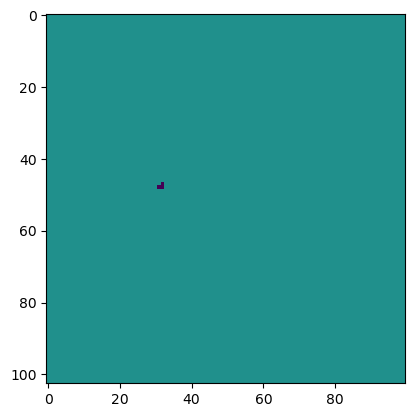

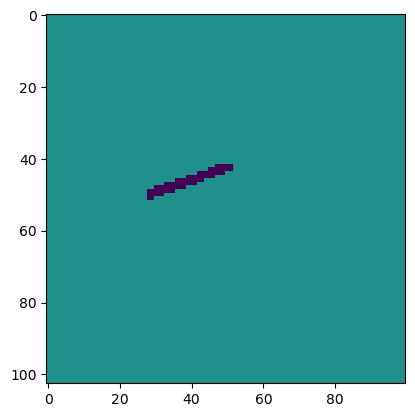

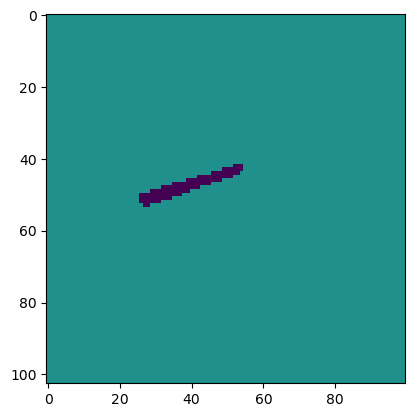

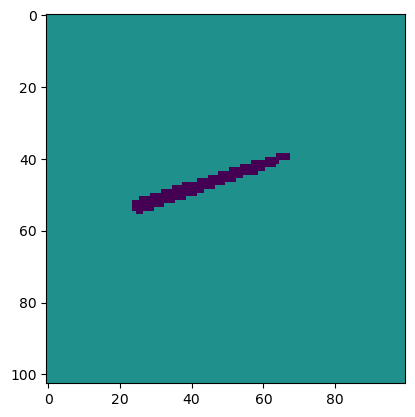

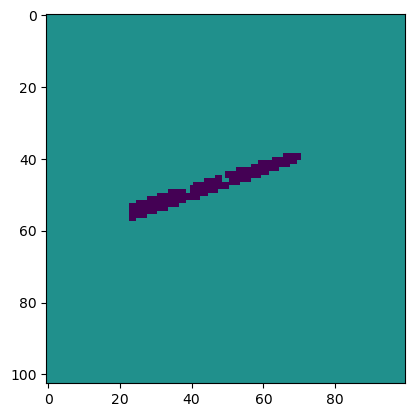

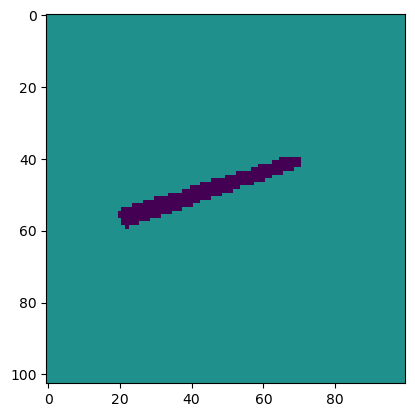

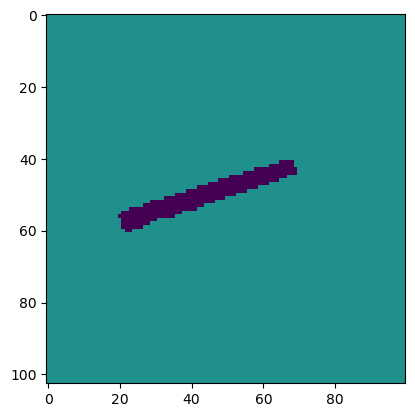

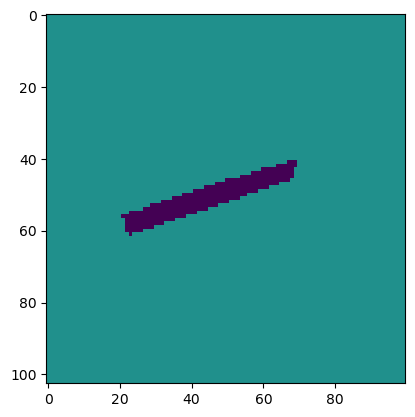

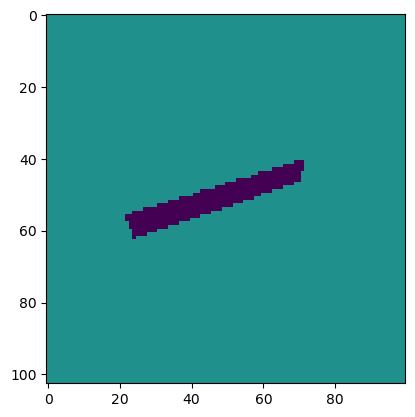

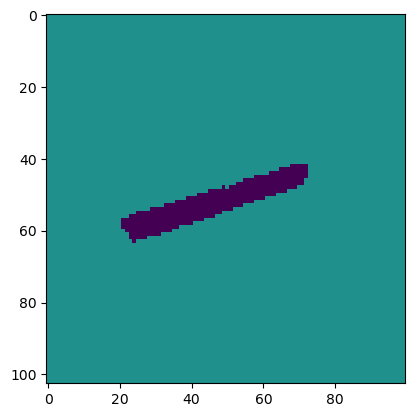

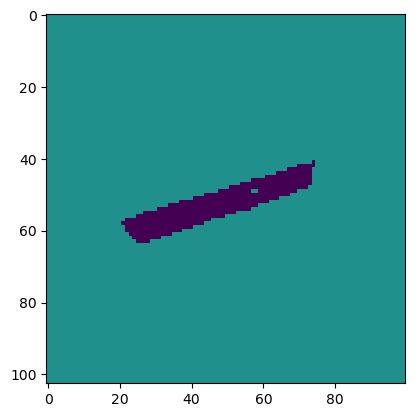

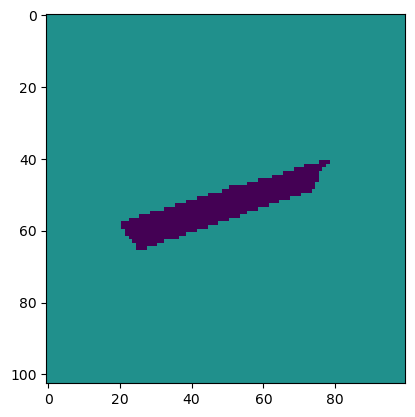

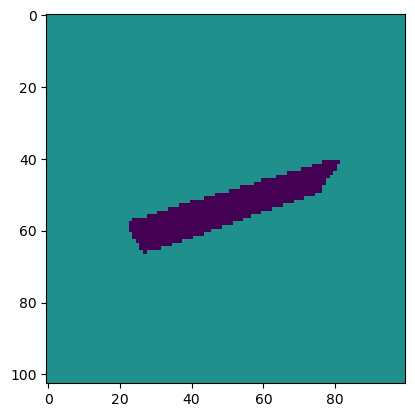

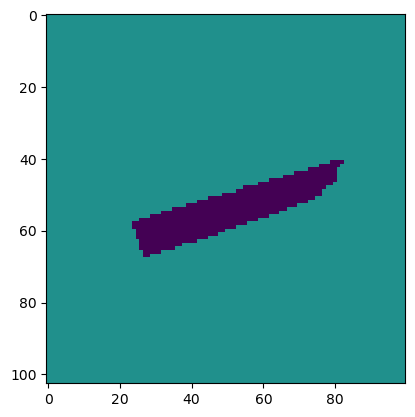

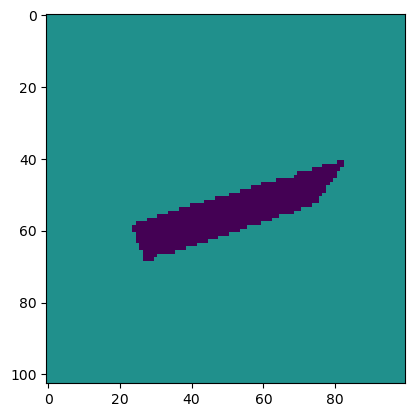

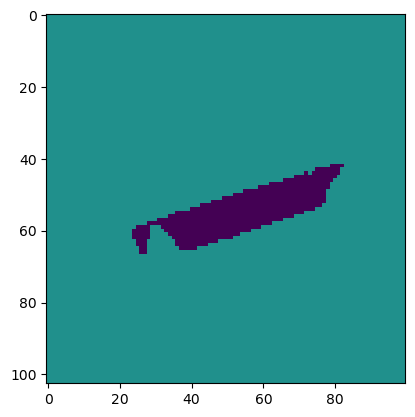

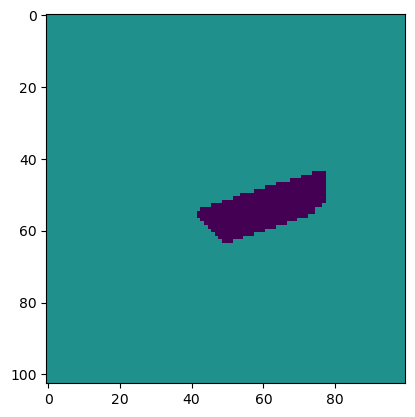

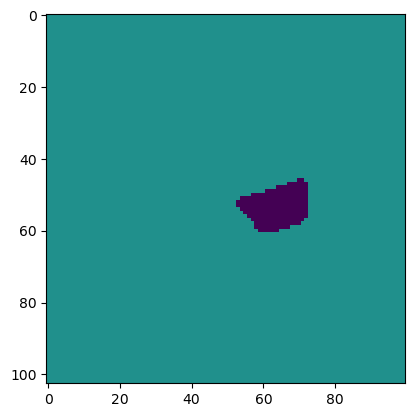

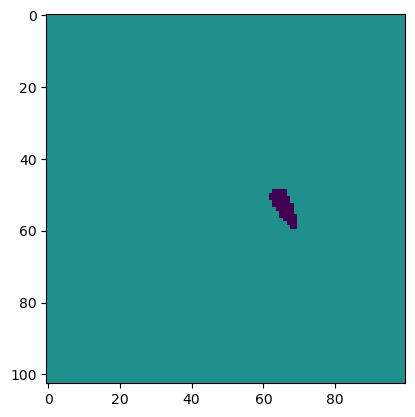

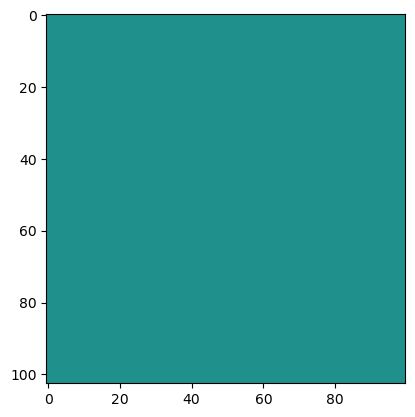

0.0
28591.0
28591.0


In [360]:
#recons.resample()
#recons.resample
moved = recons.convert_to_array(recons.adjust)
fixed = recons.fixed_d_mask

for slice_ in range(20):
    slice = slice_*5
    plt.imshow(moved[slice] - fixed[slice])
    plt.clim([-1,1])
    plt.show()
    #plt.imshow(moved[slice])
    #plt.show()
    #plt.imshow(fixed[slice])
    #plt.show()

print(np.sum(moved**2))
print(np.sum(fixed**2))
print(np.sum(np.abs(fixed-moved)))

In [ ]:

for slice_ in range(20):
    slice = slice_*5
    plt.imshow(moved[slice] - fixed[slice])
    plt.clim([-1,1])
    plt.show()
    #plt.imshow(moved[slice])
    #plt.show()
    #plt.imshow(fixed[slice])
    #plt.show()

print(np.sum(moved**2))
print(np.sum(fixed**2))
print(np.sum(fixed-moved)**2)